<a href="https://colab.research.google.com/github/chandrasantos/k-nn_algortimopreditivo_iris_UFMS/blob/main/UFMS_conjuntoIRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

k-nn_algortimopreditivo_iris_UFMS
A aprendizagem de máquina foca em desenvolver algoritmos que permitem aos computadores aprender com os dados e tomar decisões ou fazer previsões sem serem explicitamente programados para cada tarefa, identificando padrões complexos em grandes volumes de informação. As regressões servem para prever valores contínuos, como estimar o preço de um imóvel com base em suas características (área, localização) ou prever a demanda de vendas de uma loja para o próximo trimestre. As árvores de decisão são usadas para classificação, ajudando a determinar, por exemplo, o risco de crédito de um cliente (aprovar ou negar) ou em diagnósticos médicos preliminares baseados em sintomas. Um exemplo clássico do algoritmo preditivo k-NN seria em sistemas de recomendação, como os da Netflix ou Spotify, onde o algoritmo sugere um novo filme ou música baseando-se nos itens consumidos pelos 'vizinhos' (usuários com gostos mais próximos) do seu perfil.

Manipular dados

In [1]:
import pandas as pd
from sklearn.datasets import load_iris


In [2]:
iris = load_iris()
iris


{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [9]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [14]:
iris1 = iris_df.loc[iris_df.target.isin([1,2]),['petal length (cm)', 'petal width (cm)', 'target']]
iris1

,petal length (cm),petal width (cm),target
50,4.7,1.4,1
51,4.5,1.5,1
52,4.9,1.5,1
53,4.0,1.3,1
54,4.6,1.5,1
...,...,...,...
145,5.2,2.3,2
146,5.0,1.9,2
147,5.2,2.0,2
148,5.4,2.3,2


Calcular a distância

In [16]:
x = iris1[['petal length (cm)', 'petal width (cm)']]
y = iris1.target

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33, random_state=42)

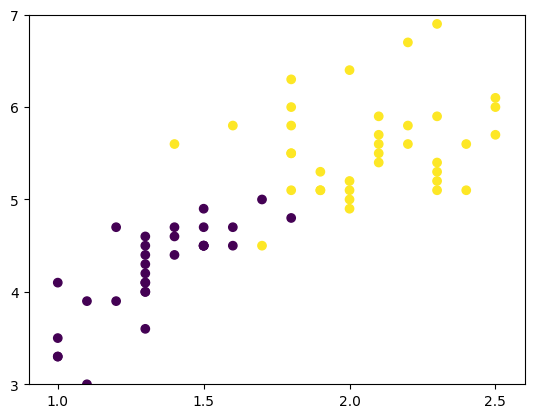

In [20]:
import matplotlib.pyplot as plt
fig, ax= plt.subplots()

ax.scatter(x=x_train['petal width (cm)'],
           y=x_train['petal length (cm)'],
           c=y_train,
           cmap='viridis')
ax.set(xlim=(0.9,2.6), xticks=[1,1.5,2,2.5],
       ylim=(3,7), yticks=[3,4,5,6,7])

plt.show()


Treinamento de dados

In [22]:
x = [[0],[1],[2],[3]]
y = [0,0,1,1]
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(x,y)
KNeighborsClassifier(...)
print (neigh.predict([[1.1]]))
print (neigh.predict_proba([[0.9]]))

[0]
[[0.66666667 0.33333333]]


In [23]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf = clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[19,  0],
       [ 6,  8]])

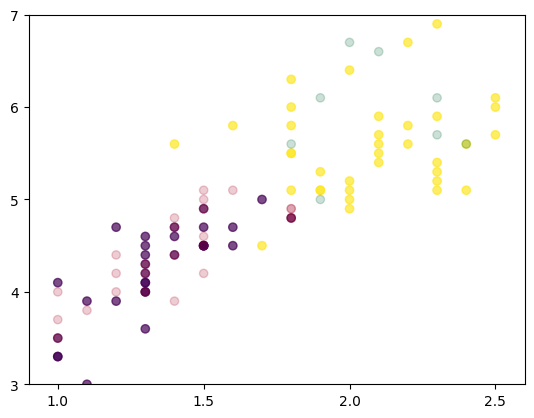

In [26]:
fig, ax= plt.subplots()

ax.scatter(x=x_train['petal width (cm)'],
           y=x_train['petal length (cm)'],
           c=y_train, alpha=0.7,
           cmap='viridis')
ax.scatter(x=x_test['petal width (cm)'],
           y=x_test['petal length (cm)'],
           c=y_pred, alpha=0.2,
           cmap='RdYlGn')

ax.set(xlim=(0.9,2.6), xticks=[1,1.5,2,2.5],
       ylim=(3,7), yticks=[3,4,5,6,7])

plt.show()

Precisão


In [27]:
x_test[y_test !=y_pred]

,petal length (cm),petal width (cm)
133,5.1,1.5
123,4.9,1.8
126,4.8,1.8
127,4.9,1.8
138,4.8,1.8
119,5.0,1.5
